<a href="https://colab.research.google.com/github/tatyanalitvin/python_for_ds_tasks/blob/dev/HW_2_1_%D0%A2%D0%B5%D1%81%D1%82%D1%83%D0%B2%D0%B0%D0%BD%D0%BD%D1%8F_%D1%81%D1%82%D0%B0%D1%82_%D0%B3%D1%96%D0%BF%D0%BE%D1%82%D0%B5%D0%B7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from statsmodels.stats.weightstats import ztest
from scipy.stats import ttest_ind

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})

In [2]:
# Helper
def check_results(p_value, alpha = 0.05):
  if(p_value < alpha):
    return "Reject H0"
  else:
    return "Fail to reject H0"

В цьому ДЗ потренуємось виконувати Z-тести для тестування гіпотез в різних задачах. Для коректної імплементації та інтерпретації тестів рекоемндую переглянути спершу документацію:

https://www.statsmodels.org/dev/generated/statsmodels.stats.weightstats.ztest.html

### Завдання 1: Z-тест для однієї вибірки

**Мета**: Перевірити, чи середнє значення вибірки відрізняється від гіпотетичного середнього.

**Припущення**: Середній ріст студентів університету вважається 170 см. Ми хочемо перевірити, чи середній ріст випадкової вибірки студентів істотно більший. Вибірка задана в змінній `heights`.

Для виконання завдання імпортуйте метод для проведення `ztest`, виконайте Z-тест з Python, виведіть p-value і зробіть заключення, чи справдилось припущення про середній зріст студентів на рівні значущості 0.05?

Використовуємо тут Z-тест, оскільки вибірка достатньо велика (більше 30 екземплярів) і можемо вважати, що її стандартне відхилення близьке до ст. відхилення генеральної сукупності, а значить - відоме.

In [3]:
heights = [174, 171, 175, 179, 170, 170, 179, 175, 169, 174, 169, 169, 173, 162, 163, 169, 166,
           173, 167, 164, 179, 170, 172, 164, 169, 175, 169, 174, 169, 169, 173, 162, 177]


mean: 170.7
std: 4.72



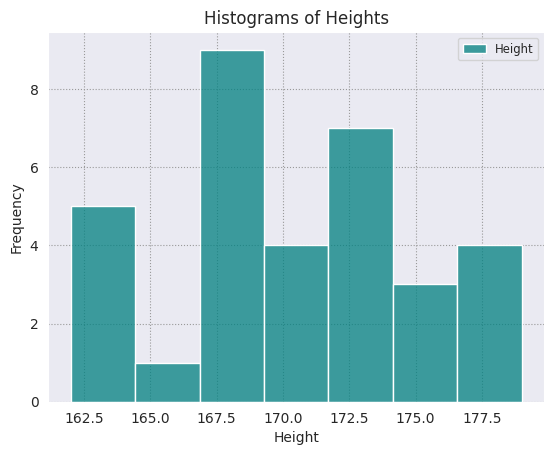

In [4]:
# Null hypothesis H0: mean = 170cm
# Alternative hypothesis H1: mean > 170cm
h0_mean_height = 170
h1_mean_height = np.mean(heights)

print(f"""
mean: {round(h1_mean_height, 2)}
std: {round(np.std(heights, ddof=1), 2)}
""")

# Plot
sns.histplot(heights, color="teal", label="Height", )

plt.xlabel('Height')
plt.ylabel('Frequency')
plt.title('Histograms of Heights')
plt.legend(fontsize='small')
plt.show()

In [5]:
ztest_score, p_value = ztest(
    heights,
    value = h0_mean_height,
    alternative = "larger"
    )

print(f"""
Z-статистика {ztest_score}
P-значення:  {p_value}

-> {check_results(p_value)}
""")



Z-статистика 0.8482235371587619
P-значення:  0.19815674571091746
      
-> Fail to reject H0



**Result:**

Недостатньо доказів на рівні alpha= 0.05 щоб прийти до висновку що середній зріст студентів є значно вищим за 170 см.

\+ cереднє значення вибірки 170.7 досить близьке до 170, отже не можемо відхилити нульову гіпотезу.

### Завдання 2: Z-тест для двох незалежних вибірок

**Завдання 2.1.**

**Мета**: Перевірити, чи існує статистична різниця між середніми оцінками двох груп студентів.

**Припущення**: Група A отримала новий навчальний курс, а група B продовжувала зі стандартним курсом. Ми перевіряємо, чи є новий курс ефективнішим.

Виконайте Z-тест з Python, виведіть p-value і зробіть заключення, чи справдилось припущення щодо студентів на рівні значущості 0.05?

In [6]:
group_a_scores = [78.55, 72.25, 79.88, 75.  , 76.54, 74.99, 87.26, 77.93, 72.71,
       82.11, 71.9 , 79.04, 68.2 , 71.36, 78.98, 81.69, 78.86, 77.42,
       76.49, 70.61, 74.4 , 75.7 , 83.29, 79.72, 69.18, 79.62, 76.07,
       74.62, 81.06, 83.15, 82.66, 73.8 , 76.45, 79.66, 82.88, 75.6 ,
       77.07, 72.47, 72.02, 82.06]

group_b_scores = [81.78, 74.64, 80.02, 76.81, 71.77, 76.81, 82.69, 74.82, 82.82,
       61.9 , 79.11, 75.44, 73.5 , 75.46, 65.06, 73.9 , 76.79, 82.39,
       72.41, 70.96, 72.49, 79.58, 76.64, 72.35, 77.57, 75.49, 79.84,
       71.49, 73.36, 73.04, 67.68, 76.48, 76.31, 75.03, 73.83, 67.92,
       72.9 , 73.29, 70.99, 74.19]


Група A mean: 77.08
Група A std: 4.37
      
Група B mean: 74.74
Група B std: 4.52



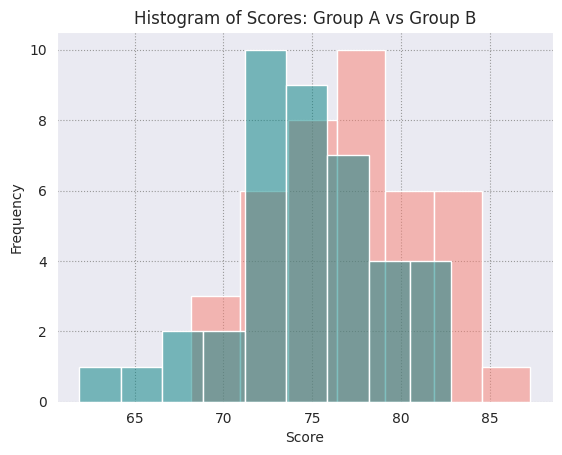

In [7]:
# H0: mean A = mean B
# H1: mean A != mean B

a_scores_mean = np.mean(group_a_scores)
b_scores_mean = np.mean(group_b_scores)
a_scores_std = np.std(group_a_scores, ddof=1)
b_scores_std = np.std(group_b_scores, ddof=1)

print(f"""
Група A mean: {round(a_scores_mean, 2)}
Група A std: {round(a_scores_std, 2)}

Група B mean: {round(b_scores_mean, 2)}
Група B std: {round(b_scores_std, 2)}
""")

# Plot
sns.histplot(group_a_scores, color="salmon", label="Group A", alpha=0.5)
sns.histplot(group_b_scores, color="teal", label="Group B", alpha=0.5)

plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Histogram of Scores: Group A vs Group B')
plt.show()

In [8]:
ztest_score, p_value = ztest(
    x1 = group_a_scores,
    x2 = group_b_scores,
    value = 0,
    alternative='two-sided',
    # usevar='pooled'
    )

print(f"""
Z-статистика {ztest_score}
P-значення:  {p_value}

-> {check_results(p_value)}
""")



Z-статистика 2.357354864751502
P-значення:  0.01840564855252801
      
-> Reject H0



**Результат:**

На рівні значущості alpha = 0.05, группа А показує інші(кращі) результати за группу Б. Відхиляємо нульову гіпотезу.

**Завдання 2.2.**


**Мета**: Побачити, як впливає розмір вибірок на результат тесту.

**Завдання**: Уявіть, що з групи А ми маємо тільки перші 5 записів, а з групи В - усі. Таке могло статись, якщо ми вже маємо результати тестів учнів за попередньою програмою, а тести за новою програмою здали наразі лише 5 учнів і ми вирішили не чекати довше.
Виберіть перші 5 записів для групи А і проведіть t-test (для цього використовуємо наступний [метод](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html)). Виведіть значення p-value. Зробіть висновок, який результат ви бачите щодо стат. значущості на рівні 0.05 для цього експерименту?

Тут проводимо t-test оскільки одна з вибірок - дуже мала.


Група A mean: 76.44
Група A std: 3.0
      
Група B mean: 74.74
Група B std: 4.52



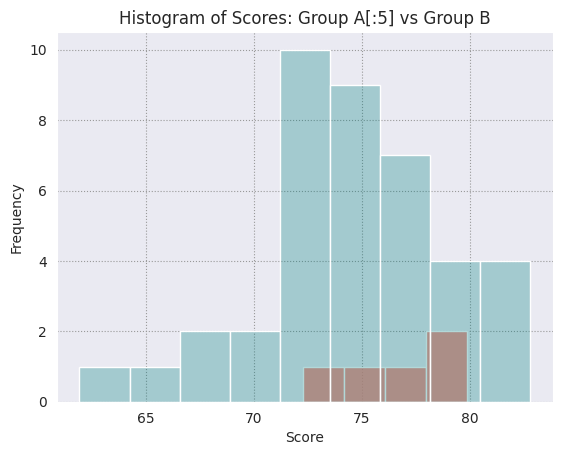

In [9]:
# H0: mean A[:5]= mean B
# H1: mean A[:5] != mean B

a_small = group_a_scores[:5]

a_scores_mean = np.mean(a_small)
b_scores_mean = np.mean(group_b_scores)
a_scores_std = np.std(a_small, ddof=1)
b_scores_std = np.std(group_b_scores, ddof=1)

print(f"""
Група A mean: {round(a_scores_mean, 2)}
Група A std: {round(a_scores_std, 2)}

Група B mean: {round(b_scores_mean, 2)}
Група B std: {round(b_scores_std, 2)}
""")

# Plot
sns.histplot(a_small, color="salmon", label="Group A", alpha=0.8)
sns.histplot(group_b_scores, color="teal", label="Group B", alpha=0.3)

plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Histogram of Scores: Group A[:5] vs Group B')
plt.show()

In [10]:
result = ttest_ind(
    a = group_a_scores[:5],
    b = group_b_scores,
)

print(f"""
T-статистика {result.statistic}
P-значення:  {result.pvalue}

-> {check_results(result.pvalue)}
""")


T-статистика 0.8167951030410814
P-значення:  0.4185479477535733
      
-> Fail to reject H0



**Висновок**

На рівні значущості 0.05 немає статистично значущих доказів того, що новий курс ефективніший за той що був.

Занадто маленька вибірка (n=5) не дає достатньої статистичної потужності (statistical power) для виявлення різниці, навіть якщо вона існує насправді.


### Завдання 3\*: Z-тест для двох **пов'язаних** вибірок

**Мета**: Перевірити, чи вплинув тренінг на продуктивність працівників, коли всі справробітники проходили тренінг.

**Припущення**: Наші працівники проходять однаковий тренінг, і ми хочемо з'ясувати, чи покращилися їхні показники після тренінгу на рівні значущості 0.05. Виконайте Z-тест з Python, виведіть p-value і зробіть заключення, чи поліпшились показники працівників на рівні значущості 0.05?

Зверніть увагу, ці вибірки повʼязані між собою, значить не буде коректно виконати z-test між ними, натомість, ми можемо порівняти, чи різниця в результатах (продуктивності співробітників) є стат значущою.

In [11]:
before_training = [57.82, 37.63, 36.8 , 55.22, 52.97, 52.5 , 53.46, 43.2 , 52.32,
       52.93, 42.86, 68.66, 54.74, 38.09, 56.57, 40.25, 57.87, 61.59,
       41.79, 59.63, 54.13, 58.22, 68.97, 47.55, 42.46, 41.1 , 41.84,
       49.23, 53.41, 52.77]

after_training = [62.47, 40.66, 42.7 , 57.69, 61.41, 56.76, 54.75, 44.06, 56.29,
       55.48, 47.28, 72.6 , 57.59, 39.39, 56.54, 42.36, 62.58, 65.01,
       42.3 , 62.98, 57.9 , 59.45, 72.28, 50.66, 43.18, 44.82, 45.96,
       54.4 , 58.52, 53.01]

In [12]:
# підрахуємо різницю продуктивності співробітників, бо вибірки показують парні дані,
# тобто дані однієї і тієї ж людини до та після навчання
d = np.array(after_training) - np.array(before_training)
d

array([ 4.65,  3.03,  5.9 ,  2.47,  8.44,  4.26,  1.29,  0.86,  3.97,
        2.55,  4.42,  3.94,  2.85,  1.3 , -0.03,  2.11,  4.71,  3.42,
        0.51,  3.35,  3.77,  1.23,  3.31,  3.11,  0.72,  3.72,  4.12,
        5.17,  5.11,  0.24])


difference mean: 3.15
difference std: 1.89



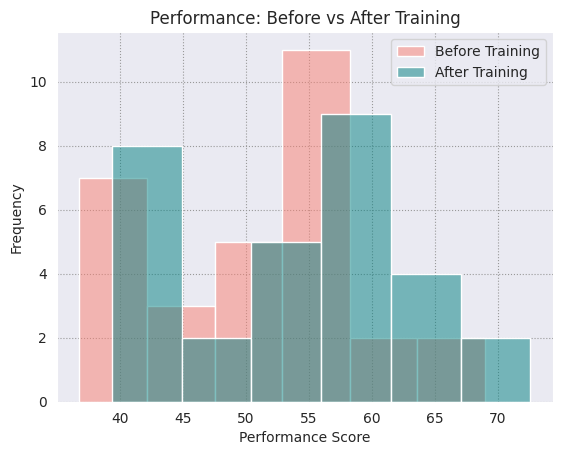

In [13]:
# H0 mean_d <= 0 (training has no positive effect or negative effect)
# H1 mean_d > 0 (training improves performance)

mean_d = np.mean(d)
training_std_d = np.std(d, ddof=1)

print(f"""
difference mean: {round(mean_d, 2)}
difference std: {round(training_std_d, 2)}
""")

# Plot
sns.histplot(before_training, color="salmon", label="Before Training", alpha=0.5)
sns.histplot(after_training, color="teal", label="After Training", alpha=0.5)

plt.xlabel('Performance Score')
plt.ylabel('Frequency')
plt.title('Performance: Before vs After Training')
plt.legend()
plt.show()

In [14]:
ztest_score, p_value = ztest(
    d,
    value=0,
    alternative='larger',
    )

print(f"""
Z-статистика {ztest_score}
P-значення:  {p_value}

-> {check_results(p_value)}
""")


Z-статистика 9.13890009623916
P-значення:  3.1545359919175505e-20
      
-> Reject H0



**Висновок:**

На рівні значущості 0.05 є статистично значущі докази того, що навчання покращило продуктивність. Відхиляємо нульову гіпотезу.